In [1]:
import io, re, pandas as pd, numpy as np

df = pd.read_csv('AlpesMaritimes/firepoint/2x2/train/occurence_default/post_process/risk_clustering_evaluation.csv')
# Décomposition du champ name selon {target}-{type_clustering}-{nbr}-Class-{regroupement}
pat = re.compile(r"^(?P<target>.+)-(?P<type_clustering>[^-]+)-(?P<nbr>\d+)-Class-(?P<regroupement>.+)$")
parts = df["name"].str.extract(pat)
df = pd.concat([parts, df.drop(columns=["name"])], axis=1)
df["nbr"] = df["nbr"].astype(int)

# colonnes utiles dans une vue “propre”
cols = ["target","type_clustering","nbr","regroupement","spearman","kendall","pearson","ss"]
df = df[cols].copy()

df.head()

,target,type_clustering,nbr,regroupement,spearman,kendall,pearson,ss
0,nbsinister,kmeans,5,Cluster,1.0,1.0,0.999806,0.999853
1,nbsinister,gm,5,Dept,1.0,1.0,0.999806,0.999853
2,nbsinister,gm,5,Season,1.0,1.0,0.999806,0.999853
3,nbsinister,gm,5,Cluster,1.0,1.0,0.999806,0.999853
4,nbsinister,kmeans,5,Dept,1.0,1.0,0.999806,0.999853


In [2]:
df

,target,type_clustering,nbr,regroupement,spearman,kendall,pearson,ss
0,nbsinister,kmeans,5,Cluster,1.000000,1.000000,0.999806,0.999853
1,nbsinister,gm,5,Dept,1.000000,1.000000,0.999806,0.999853
2,nbsinister,gm,5,Season,1.000000,1.000000,0.999806,0.999853
3,nbsinister,gm,5,Cluster,1.000000,1.000000,0.999806,0.999853
4,nbsinister,kmeans,5,Dept,1.000000,1.000000,0.999806,0.999853
5,nbsinister,kmeans,5,Season,1.000000,1.000000,0.999806,0.999853
6,nbsinister,egpd,5,Cluster,1.000000,0.999992,0.993525,0.999105
7,nbsinister,egpd,5,Season,1.000000,0.999992,0.993525,0.999105
8,nbsinister,egpd,5,Dept,1.000000,0.999992,0.993525,0.999105
9,ressource,gm,5,Dept,0.999855,0.997005,0.839650,0.962332


In [3]:
def best_by_metric(dfin, metric="ss"):
    # maximise la métrique choisie
    idx = dfin.groupby("target")[metric].idxmax()
    return dfin.loc[idx].sort_values("target").reset_index(drop=True)

best_ss   = best_by_metric(df, metric="ss")
best_spr  = best_by_metric(df, metric="spearman")
best_kend = best_by_metric(df, metric="kendall")
best_pear = best_by_metric(df, metric="pearson")

print("Top par ss:\n", best_ss[["target","type_clustering","nbr","regroupement","ss"]])

Top par ss:
               target type_clustering  nbr regroupement        ss
0         nbsinister          kmeans    5      Cluster  0.999853
1          ressource              gm    5         Dept  0.962332
2  time_intervention              gm    5         Dept  0.899667


In [4]:
def best_weighted(dfin, weights=None, norm="minmax"):
    """
    weights: dict comme {"spearman":0.3,"kendall":0.3,"pearson":0.2,"ss":0.2}
    norm: "minmax" (par target) ou "z" (z-score par target)
    """
    if weights is None:
        weights = {"spearman":0.3,"kendall":0.3,"pearson":0.2,"ss":0.2}
    metrics = list(weights.keys())
    out = []
    for t, g in dfin.groupby("target"):
        X = g[metrics].copy()
        if norm == "minmax":
            X = (X - X.min()) / (X.max() - X.min() + 1e-12)
        elif norm == "z":
            X = (X - X.mean()) / (X.std(ddof=0) + 1e-12)
        score = (X * pd.Series(weights)).sum(axis=1)
        g2 = g.copy()
        g2["score_weighted"] = score
        best = g2.loc[g2["score_weighted"].idxmax()]
        out.append(best)
    res = pd.DataFrame(out).sort_values("target").reset_index(drop=True)
    return res

best_w = best_weighted(df, weights={"spearman":0.25,"kendall":0.25,"pearson":0.25,"ss":0.25}, norm="minmax")
best_w[["target","type_clustering","nbr","regroupement","score_weighted"]]


,target,type_clustering,nbr,regroupement,score_weighted
0,nbsinister,kmeans,5,Cluster,0.999993
1,ressource,gm,5,Dept,0.902360
2,time_intervention,egpd,5,Dept,0.850364


In [5]:
def best_by_mean_rank(dfin, metrics=("spearman","kendall","pearson","ss")):
    out = []
    for t, g in dfin.groupby("target"):
        ranks = pd.DataFrame({m: g[m].rank(ascending=False, method="average") for m in metrics})
        mean_rank = ranks.mean(axis=1)
        g2 = g.copy()
        g2["mean_rank"] = mean_rank
        best = g2.loc[g2["mean_rank"].idxmin()]
        out.append(best)
    return pd.DataFrame(out).sort_values("target").reset_index(drop=True)

best_rank = best_by_mean_rank(df)
best_rank[["target","type_clustering","nbr","regroupement","mean_rank"]]

,target,type_clustering,nbr,regroupement,mean_rank
0,nbsinister,kmeans,5,Cluster,3.50
1,ressource,gm,5,Dept,2.25
2,time_intervention,egpd,5,Dept,2.75


In [6]:
def pareto_front(g, metrics=("spearman","kendall","pearson","ss")):
    # conserve les configs non-dominées (personne n'est >= sur toutes les métriques et > sur au moins une)
    A = g[metrics].to_numpy()
    keep = np.ones(len(g), dtype=bool)
    for i in range(len(g)):
        if not keep[i]:
            continue
        # j domine i ssi A[j] >= A[i] partout et > quelque part
        dom = np.all(A >= A[i], axis=1) & np.any(A > A[i], axis=1)
        dom[i] = False
        if dom.any():
            keep[i] = False
    return g.loc[keep]

def pareto_by_target(dfin, metrics=["spearman","kendall","pearson","ss"]):
    res = []
    for t, g in dfin.groupby("target"):
        pf = pareto_front(g, metrics)
        pf = pf.assign(target=t).copy()
        res.append(pf)
    return pd.concat(res, ignore_index=True)

pareto = pareto_by_target(df)
# Pour chaque target, tu peux encore trier le front par une métrique secondaire (ex: ss)
pareto_sorted = pareto.sort_values(["target","ss"], ascending=[True,False])
pareto_sorted[["target","type_clustering","nbr","regroupement","spearman","kendall","pearson","ss"]]

,target,type_clustering,nbr,regroupement,spearman,kendall,pearson,ss
0,nbsinister,kmeans,5,Cluster,1.000000,1.000000,0.999806,0.999853
1,nbsinister,gm,5,Dept,1.000000,1.000000,0.999806,0.999853
2,nbsinister,gm,5,Season,1.000000,1.000000,0.999806,0.999853
3,nbsinister,gm,5,Cluster,1.000000,1.000000,0.999806,0.999853
4,nbsinister,kmeans,5,Dept,1.000000,1.000000,0.999806,0.999853
5,nbsinister,kmeans,5,Season,1.000000,1.000000,0.999806,0.999853
6,ressource,gm,5,Dept,0.999855,0.997005,0.839650,0.962332
7,ressource,gm,5,Season,0.999856,0.996981,0.831338,0.956739
8,ressource,kmeans,5,Dept,0.998232,0.986452,0.863620,0.933277
9,ressource,kmeans,5,Season,0.998240,0.986636,0.867004,0.932229


In [7]:
rng = np.random.default_rng(42)

def best_under_random_weights(dfin, n_draws=2000, metrics=("spearman","kendall","pearson","ss")):
    winners = []
    # pré-groupe par target
    groups = {t:g for t,g in dfin.groupby("target")}
    for t, g in groups.items():
        G = g.reset_index(drop=True).copy()
        X = G[list(metrics)]
        counts = np.zeros(len(G), dtype=int)
        for _ in range(n_draws):
            w = rng.random(len(metrics))
            w = w / w.sum()
            # min-max par target pour éviter l’échelle
            Xn = (X - X.min()) / (X.max() - X.min() + 1e-12)
            scores = (Xn * w).sum(axis=1)
            counts[np.argmax(scores)] += 1
        G["vote_share"] = counts / n_draws
        winners.append(G.loc[G["vote_share"].idxmax()])
    res = pd.DataFrame(winners).sort_values("target").reset_index(drop=True)
    return res

best_robust = best_under_random_weights(df, n_draws=2000)
best_robust[["target","type_clustering","nbr","regroupement","vote_share"]]


,target,type_clustering,nbr,regroupement,vote_share
0,nbsinister,kmeans,5,Cluster,1.0000
1,ressource,gm,5,Dept,0.9935
2,time_intervention,egpd,5,Dept,0.9130


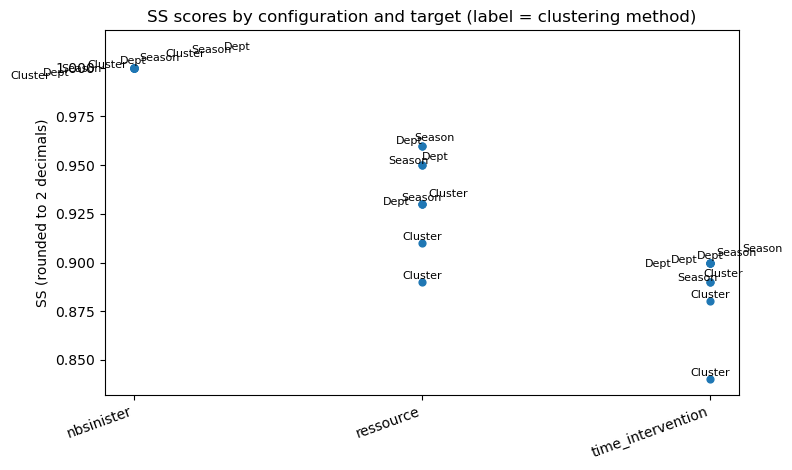

/tmp/ipykernel_11962/771259118.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(best["target"], rotation=20, ha="right")


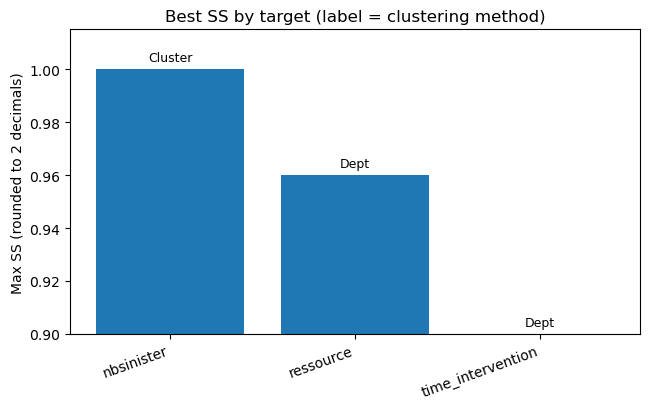

In [8]:
def plot_ss_by_target_with_method(df) -> None:
    """
    Lit un DataFrame (colonnes: target, regroupement, nbr, ss, ...) :
      - arrondit ss à 2 décimales,
      - trace :
         1) un scatter ss vs target, avec labels "regroupement" et désuperposition des labels
         2) un bar chart du meilleur ss par target, étiqueté par le regroupement gagnant
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # Préparation
    df = df.copy()
    df["nbr"] = df["nbr"].astype(int)
    df["ss_round"] = df["ss"].round(2)

    # ========== PLOT 1 : SCATTER ==========
    fig, ax = plt.subplots(figsize=(8, 4.8))

    # Axes X catégoriels
    targets_cat = df["target"].astype("category")
    df["_x"] = targets_cat.cat.codes.values  # entiers 0..K-1
    xlabels = list(targets_cat.cat.categories)

    # Scatter de base
    ax.scatter(df["_x"], df["ss_round"], s=24)

    # Désuperposition des labels : offsets par groupe (target, ss_round)
    # Espace d'offset proportionnel à l'étendue des données
    y_min, y_max = float(df["ss_round"].min()), float(df["ss_round"].max())
    y_span = max(y_max - y_min, 1e-6)
    x_jitter_unit = 0.09  # ~10% de l'espacement entre catégories
    y_jitter_unit = 0.012 * y_span

    # Pour chaque groupe de points superposés, on crée des offsets centrés : -m, ..., 0, ..., +m
    grouped = df.groupby(["target", "ss_round"], sort=False)
    for (_, _), idx in grouped.groups.items():
        ids = list(idx) if isinstance(idx, (list, tuple)) else list(idx)
        n = len(ids)
        if n == 1:
            i = ids[0]
            ax.text(df.loc[i, "_x"], df.loc[i, "ss_round"] + 0.004*y_span,
                    str(df.loc[i, "regroupement"]),
                    fontsize=8, ha="center", va="bottom")
        else:
            # offsets centrés : p.ex. pour n=3 -> [-1, 0, +1], pour n=4 -> [-1.5,-0.5,0.5,1.5]
            offsets = np.arange(n) - (n - 1) / 2.0
            # Échelle des offsets (un peu + en X que Y pour la lisibilité)
            for k, i in enumerate(ids):
                x_off = offsets[k] * x_jitter_unit
                y_off = offsets[k] * y_jitter_unit
                ax.text(df.loc[i, "_x"] + x_off,
                        df.loc[i, "ss_round"] + 0.004*y_span + y_off,
                        str(df.loc[i, "regroupement"]),
                        fontsize=8, ha="center", va="bottom")

    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=20, ha="right")
    ax.set_ylabel("SS (rounded to 2 decimals)")
    ax.set_title("SS scores by configuration and target (label = clustering method)")

    # Marges verticales pour éviter les labels coupés
    ax.set_ylim(y_min - 0.05*y_span, y_max + 0.12*y_span)

    fig.tight_layout()
    plt.show()

    # ========== PLOT 2 : BAR CHART (meilleur ss par target) ==========
    best_idx = df.groupby("target")["ss"].idxmax()
    best = df.loc[best_idx].copy()
    best["ss_round"] = best["ss"].round(2)

    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    bars = ax.bar(best["target"], best["ss_round"])

    # Décale légèrement les labels au-dessus des barres
    y_min2, y_max2 = float(best["ss_round"].min()), float(best["ss_round"].max())
    y_span2 = max(y_max2 - y_min2, 1e-6)
    for i, (xlab, y, lbl) in enumerate(zip(best["target"], best["ss_round"], best["regroupement"])):
        ax.text(i, y + 0.02*y_span2, f"{lbl}", ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Max SS (rounded to 2 decimals)")
    ax.set_title("Best SS by target (label = clustering method)")
    ax.set_xticklabels(best["target"], rotation=20, ha="right")
    ax.set_ylim(y_min2, y_max2 + 0.15*y_span2)

    fig.tight_layout()
    plt.show()

plot_ss_by_target_with_method(df)